# Primary Model: Social Jetlag, hs-CRP, and PHQ-9

This notebook contains only the team's primary regression model. It uses a **survey-weighted Gaussian generalized linear model with an identity link** to test whether hs-CRP modifies the association between social jetlag and PHQ-9 score.

- Outcome: PHQ-9 score (0–27)
- Exposure: social jetlag (hours)
- Interaction: social jetlag × log(hs-CRP)
- Primary sample: complete-case hs-CRP dataset
- Survey design: NHANES examination weights, strata, and PSUs

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import svy
from IPython.display import display

# If running in Colab and svy/polars are unavailable, run once:
# %pip install svy polars

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent

possible_data_paths = [
    project_root / 'data' / 'processed' / 'nhanes_primary_hscrp_model.csv',
    Path('/content/drive/MyDrive/capstone_outputs/processed/nhanes_primary_hscrp_model.csv'),
]
data_path = next((path for path in possible_data_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        'Primary model CSV not found. Download it from capstone_outputs or '
        'add the capstone_outputs shortcut to My Drive.'
    )

data = pd.read_csv(data_path)
print(f'Loaded: {data_path}')
print(f'Participants: {len(data):,}')

Matplotlib is building the font cache; this may take a moment.


Loaded: /Users/yasthilsingh/PycharmProjects/capstone/data/processed/nhanes_primary_hscrp_model.csv
Participants: 6,562


## 1. Quick data check

In [2]:
model_columns = [
    'phq9_score',
    'social_jetlag_hours',
    'log_hs_crp',
    'weighted_average_sleep_duration',
    'age',
    'sex',
    'race_ethnicity',
    'income_poverty_ratio',
    'any_recreational_activity',
    'smoking_status',
    'WTMECPRP',
    'SDMVSTRA',
    'SDMVPSU',
]

missing_columns = sorted(set(model_columns) - set(data.columns))
if missing_columns:
    raise KeyError(f'Missing model columns: {missing_columns}')
if data[model_columns].isna().any().any():
    raise ValueError('The primary complete-case file contains missing model values.')

sample_check = pd.DataFrame({
    'measure': [
        'Participants', 'Unique participants', 'Strata',
        'PSU-stratum pairs', 'PHQ-9 minimum', 'PHQ-9 maximum',
    ],
    'value': [
        len(data),
        data['SEQN'].nunique(),
        data['SDMVSTRA'].nunique(),
        len(data[['SDMVSTRA', 'SDMVPSU']].drop_duplicates()),
        data['phq9_score'].min(),
        data['phq9_score'].max(),
    ],
})
display(sample_check)

,measure,value
0,Participants,6562.0
1,Unique participants,6562.0
2,Strata,24.0
3,PSU-stratum pairs,49.0
4,PHQ-9 minimum,0.0
5,PHQ-9 maximum,27.0


## 2. Fit the primary survey-weighted model

The model adjusts for weighted average sleep duration, age, sex, race/ethnicity, income-to-poverty ratio, recreational physical activity, and smoking status. The Gaussian family and identity link estimate differences directly in PHQ-9 points.

In [3]:
design = svy.Design(
    stratum='SDMVSTRA',
    psu='SDMVPSU',
    wgt='WTMECPRP',
)
sample = svy.Sample(
    data=pl.from_pandas(data, include_index=False),
    design=design,
)

predictors = [
    'social_jetlag_hours',
    'log_hs_crp',
    svy.Cross('social_jetlag_hours', 'log_hs_crp'),
    'weighted_average_sleep_duration',
    'age',
    svy.Cat('sex', ref='Female'),
    svy.Cat('race_ethnicity', ref='Non-Hispanic White'),
    'income_poverty_ratio',
    'any_recreational_activity',
    svy.Cat('smoking_status', ref='Never'),
]

primary_model = sample.glm.fit(
    y='phq9_score',
    x=predictors,
    family='gaussian',
    link='identity',
    drop_nulls=True,
    alpha=0.05,
)
print('Primary survey-weighted Gaussian GLM fitted successfully.')

Primary survey-weighted Gaussian GLM fitted successfully.


## 3. Model results

In [4]:
coefficient_table = pd.DataFrame([
    {
        'term': coefficient.term,
        'estimate': coefficient.est,
        'standard_error': coefficient.se,
        'conf_low': coefficient.lci,
        'conf_high': coefficient.uci,
        'p_value': coefficient.wald.p_value,
    }
    for coefficient in primary_model.fitted.coefs
])
display(coefficient_table.round(4))

,term,estimate,standard_error,conf_low,conf_high,p_value
0,_intercept_,6.5053,0.5880,5.1951,7.8155,0.0000
1,social_jetlag_hours,-0.0658,0.0660,-0.2128,0.0812,0.3422
2,log_hs_crp,0.2188,0.0700,0.0627,0.3748,0.0108
3,social_jetlag_hours:log_hs_crp,0.0112,0.0320,-0.0602,0.0825,0.7342
4,weighted_average_sleep_duration,-0.1250,0.0466,-0.2288,-0.0212,0.0230
5,age,-0.0155,0.0047,-0.0259,-0.0051,0.0078
6,sex_Male,-0.8720,0.1201,-1.1395,-0.6044,0.0000
7,race_ethnicity_Mexican American,-0.4895,0.2295,-1.0010,0.0219,0.0588
8,race_ethnicity_Non-Hispanic Asian,-0.6706,0.1458,-0.9955,-0.3458,0.0010
9,race_ethnicity_Non-Hispanic Black,-0.5270,0.1550,-0.8723,-0.1816,0.0068


In [5]:
interaction_term = 'social_jetlag_hours:log_hs_crp'
primary_result = coefficient_table.loc[
    coefficient_table['term'] == interaction_term
].copy()
if len(primary_result) != 1:
    raise ValueError('Expected exactly one social jetlag × log(hs-CRP) coefficient.')

primary_result.insert(0, 'model', 'Survey-weighted Gaussian GLM')
primary_result.insert(1, 'outcome', 'PHQ-9 score (0-27)')
primary_result.insert(2, 'participants', len(data))
display(primary_result.round(4))

result = primary_result.iloc[0]
print(
    f"Primary interaction: beta={result['estimate']:.4f}, "
    f"95% CI [{result['conf_low']:.4f}, {result['conf_high']:.4f}], "
    f"p={result['p_value']:.4f}"
)

,model,outcome,participants,term,estimate,standard_error,conf_low,conf_high,p_value
3,Survey-weighted Gaussian GLM,PHQ-9 score (0-27),6562,social_jetlag_hours:log_hs_crp,0.0112,0.032,-0.0602,0.0825,0.7342


Primary interaction: beta=0.0112, 95% CI [-0.0602, 0.0825], p=0.7342


## 4. Key primary-model terms

The table below separates the social-jetlag main term, log(hs-CRP) main term, and their interaction. Because the model includes an interaction, each main term is conditional on the other interacting variable equaling zero.

In [6]:
key_term_names = [
    'social_jetlag_hours',
    'log_hs_crp',
    'social_jetlag_hours:log_hs_crp',
]
key_terms = coefficient_table.loc[
    coefficient_table['term'].isin(key_term_names)
].copy()
key_terms['interpretation'] = key_terms['term'].map({
    'social_jetlag_hours': 'SJL association when log(hs-CRP) = 0',
    'log_hs_crp': 'log(hs-CRP) association when SJL = 0 hours',
    'social_jetlag_hours:log_hs_crp': 'Change in the SJL association as log(hs-CRP) increases',
})
display(key_terms[[
    'term', 'estimate', 'conf_low', 'conf_high', 'p_value', 'interpretation'
]].round(4))

,term,estimate,conf_low,conf_high,p_value,interpretation
1,social_jetlag_hours,-0.0658,-0.2128,0.0812,0.3422,SJL association when log(hs-CRP) = 0
2,log_hs_crp,0.2188,0.0627,0.3748,0.0108,log(hs-CRP) association when SJL = 0 hours
3,social_jetlag_hours:log_hs_crp,0.0112,-0.0602,0.0825,0.7342,Change in the SJL association as log(hs-CRP) i...


## 5. Save the primary results for the sensitivity notebook

The primary model has already been fitted above. This block does **not** rerun or change the model, its coefficients, or its statistical conclusions. It makes a copy of the completed results table, renames a few columns and variables to match the names used in Mengyao's sensitivity notebook, and saves the copy as `reports/tables/primary_model_result.csv`.

Mengyao's notebook uses this small reference file to compare the primary estimates with each sensitivity analysis. The file contains only model results and the sample size—no participant-level data. Anyone running the sensitivity notebook should run this primary notebook first so the reference file is created.

In [7]:
team_result = coefficient_table.rename(columns={
    'standard_error': 'std_error',
    'conf_low': 'ci_low',
    'conf_high': 'ci_high',
}).copy()
team_result['term'] = team_result['term'].replace({
    'social_jetlag_hours': 'sjl_midpoint',
    'log_hs_crp': 'log_crp',
    'social_jetlag_hours:log_hs_crp': 'sjl_midpoint:log_crp',
})
team_result.insert(0, 'outcome', 'phq9_score')
team_result.insert(0, 'model', 'survey_weighted_gaussian_identity')
team_result['family'] = 'gaussian'
team_result['link'] = 'identity'
team_result['n'] = len(data)

team_result_path = project_root / 'reports' / 'tables' / 'primary_model_result.csv'
team_result_path.parent.mkdir(parents=True, exist_ok=True)
team_result.to_csv(team_result_path, index=False)
print(f'Saved sensitivity reference table: {team_result_path}')
display(team_result.loc[team_result['term'].isin([
    'sjl_midpoint', 'log_crp', 'sjl_midpoint:log_crp'
])].round(4))

Saved sensitivity reference table: /Users/yasthilsingh/PycharmProjects/capstone/reports/tables/primary_model_result.csv


,model,outcome,term,estimate,std_error,ci_low,ci_high,p_value,family,link,n
1,survey_weighted_gaussian_identity,phq9_score,sjl_midpoint,-0.0658,0.066,-0.2128,0.0812,0.3422,gaussian,identity,6562
2,survey_weighted_gaussian_identity,phq9_score,log_crp,0.2188,0.070,0.0627,0.3748,0.0108,gaussian,identity,6562
3,survey_weighted_gaussian_identity,phq9_score,sjl_midpoint:log_crp,0.0112,0.032,-0.0602,0.0825,0.7342,gaussian,identity,6562


## 6. Post-analysis check: social-jetlag distribution

This survey-weighted histogram helps identify the large zero group, skewness, and extreme values before choosing category cutoffs in sensitivity analyses. Values of six hours or more are combined in the final bin so the main distribution remains visible.

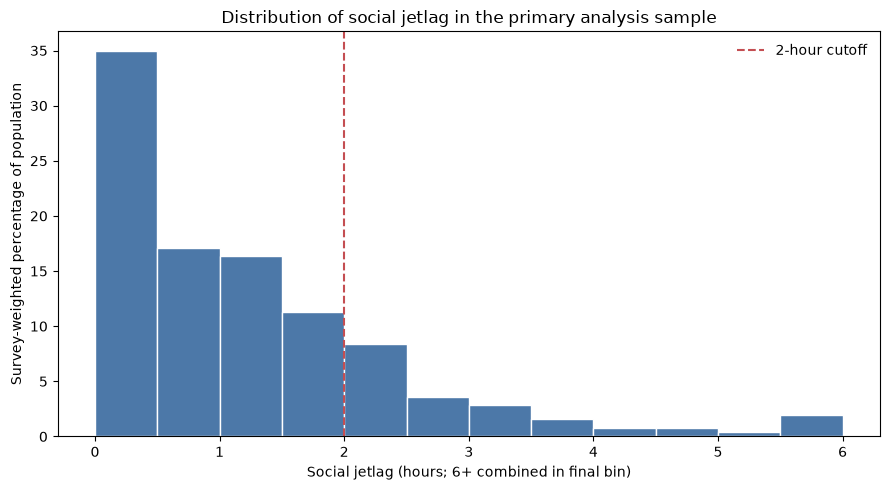

,measure,value
0,Unweighted median SJL (hours),0.75
1,Unweighted IQR (hours),0.00 to 1.62
2,Survey-weighted exactly 0 hours (%),28.822548
3,Survey-weighted 2+ hours (%),20.276296
4,Participants with 6+ hours,118


In [8]:
sjl = data['social_jetlag_hours']
normalized_weights = 100 * data['WTMECPRP'] / data['WTMECPRP'].sum()
sjl_for_plot = sjl.clip(upper=6)
bins = np.arange(0, 6.5, 0.5)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    sjl_for_plot,
    bins=bins,
    weights=normalized_weights,
    color='#4C78A8',
    edgecolor='white',
)
ax.axvline(2, color='#C44E52', linestyle='--', linewidth=1.5, label='2-hour cutoff')
ax.set(
    xlabel='Social jetlag (hours; 6+ combined in final bin)',
    ylabel='Survey-weighted percentage of population',
    title='Distribution of social jetlag in the primary analysis sample',
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

distribution_summary = pd.DataFrame({
    'measure': [
        'Unweighted median SJL (hours)',
        'Unweighted IQR (hours)',
        'Survey-weighted exactly 0 hours (%)',
        'Survey-weighted 2+ hours (%)',
        'Participants with 6+ hours',
    ],
    'value': [
        sjl.median(),
        f"{sjl.quantile(0.25):.2f} to {sjl.quantile(0.75):.2f}",
        normalized_weights.loc[sjl.eq(0)].sum(),
        normalized_weights.loc[sjl.ge(2)].sum(),
        int(sjl.ge(6).sum()),
    ],
})
display(distribution_summary)

## 7. Interpretation

The social jetlag × log(hs-CRP) interaction coefficient is approximately **0.011 PHQ-9 points** (95% CI −0.060 to 0.083; p = 0.734). The confidence interval includes zero and the p-value is not statistically significant.

The log(hs-CRP) main term is statistically significant: **β = 0.219 PHQ-9 points** (95% CI 0.063 to 0.375; p = 0.011). In this interaction model, that coefficient describes the association between log(hs-CRP) and PHQ-9 specifically when social jetlag equals zero hours. It should not be described as an unconditional or causal hs-CRP effect. Mean-centering social jetlag would make this main term represent the association at average social jetlag without changing the interaction estimate.

The primary model does **not** provide evidence that hs-CRP changes or amplifies the association between social jetlag and depressive symptom severity. This is a null interaction finding; it does not prove that no relationship exists.

This notebook intentionally contains only the primary model. The HbA1c, hs-CRP ≤10 mg/L, binary PHQ-9, age, work-schedule, and other sensitivity analyses are kept in separate notebooks.